### Machine Learning Part

In [ ]:
pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.7 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels as s
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.vector_ar import var_model
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests as gct
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score

In [ ]:
# Import pmdarima library
import pmdarima as pm
from pmdarima import utils
from pmdarima import arima
from pmdarima import model_selection
from statistics import mean
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
# Read csvs
eth = pd.read_csv("ml-003_master_file.csv")

In [ ]:
corr_matrix = eth.corr()

sns.heatmap(corr_matrix, annot = True, cmap = 'Blues', fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()

### 1.Features

I just pick up the following features.<br>
- USD-based eth price
- USD-based eth volume
- transacion counts
- distinct number of blocks
- distinct number of miners
- Average block size
- 10-year real interest rate
- 1-year real interest rate

### 2.Plot data

In [ ]:
# download BTC-USD data
btc_usd = yf.download('BTC-USD', start='2021-08-06', end='2024-03-01')
eth_usd = yf.download('ETH-USD', start='2021-08-06', end='2024-03-01')

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


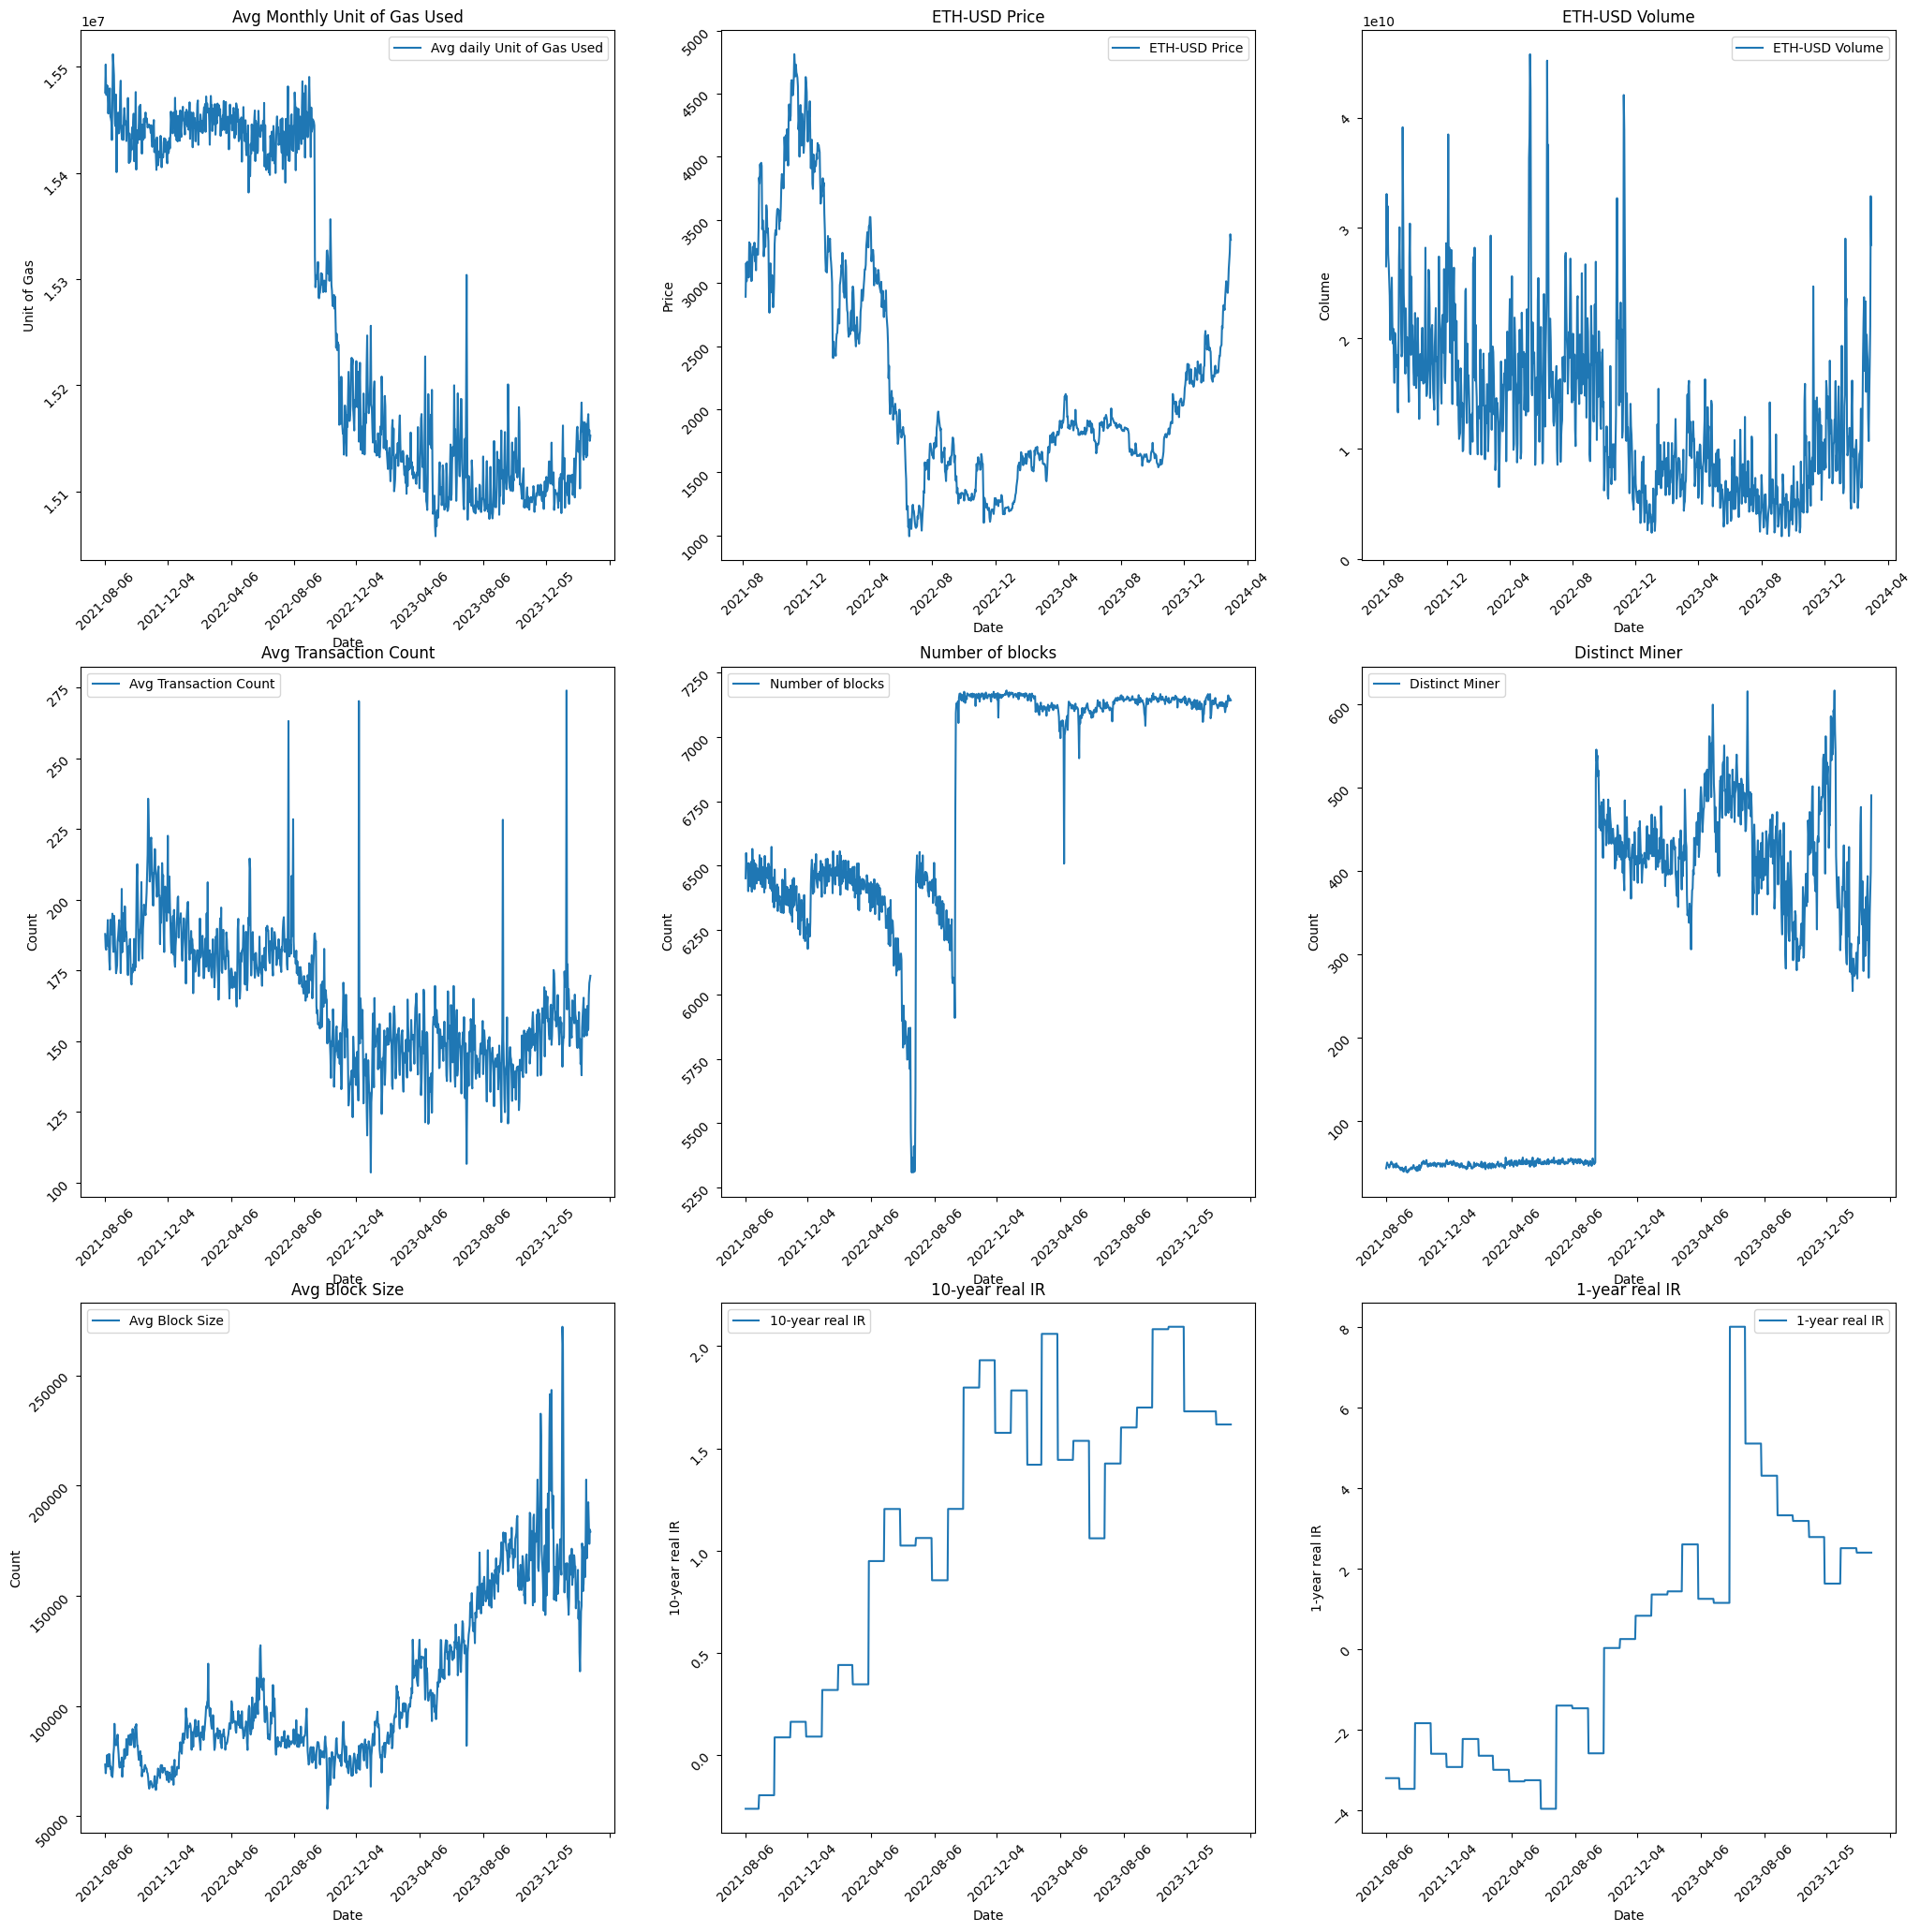

In [ ]:
# Plot graphs ETH
# Create a figure and a set of subplots
fig, axs = plt.subplots(3, 3, figsize=(25,25))

# Plot daily gas used
axs[0][0].plot(eth['date'], eth['avg_daily_gas_used'], label='Avg daily Unit of Gas Used')
axs[0][0].set_title('Avg Monthly Unit of Gas Used')
axs[0][0].set_xlabel('Date')
axs[0][0].set_ylabel('Unit of Gas')
axs[0][0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[0][0].tick_params(rotation=45)
axs[0][0].legend()

# Plot eth price
axs[0][1].plot(eth_usd['Adj Close'], label='ETH-USD Price')
axs[0][1].set_title('ETH-USD Price')
axs[0][1].set_xlabel('Date')
axs[0][1].set_ylabel('Price')
axs[0][1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[0][1].tick_params(rotation=45)
axs[0][1].legend()

# Plot eth volume
axs[0][2].plot(eth_usd['Volume'], label='ETH-USD Volume')
axs[0][2].set_title('ETH-USD Volume')
axs[0][2].set_xlabel('Date')
axs[0][2].set_ylabel('Colume')
axs[0][2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[0][2].tick_params(rotation=45)
axs[0][2].legend()

# Plot average transaction count
axs[1][0].plot(eth['date'], eth['avg_transacion_count'], label='Avg Transaction Count')
axs[1][0].set_title('Avg Transaction Count')
axs[1][0].set_xlabel('Date')
axs[1][0].set_ylabel('Count')
axs[1][0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[1][0].tick_params(rotation=45)
axs[1][0].legend()

# Plot number of blocks
axs[1][1].plot(eth['date'], eth['distinct_block_number'], label='Number of blocks')
axs[1][1].set_title('Number of blocks')
axs[1][1].set_xlabel('Date')
axs[1][1].set_ylabel('Count')
axs[1][1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[1][1].tick_params(rotation=45)
axs[1][1].legend()

# Plot distinct number of miners
axs[1][2].plot(eth['date'], eth['distinct_miner'], label='Distinct Miner')
axs[1][2].set_title('Distinct Miner')
axs[1][2].set_xlabel('Date')
axs[1][2].set_ylabel('Count')
axs[1][2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[1][2].tick_params(rotation=45)
axs[1][2].legend()

# Plot block size
axs[2][0].plot(eth['date'], eth['avg_block_size'], label='Avg Block Size')
axs[2][0].set_title('Avg Block Size')
axs[2][0].set_xlabel('Date')
axs[2][0].set_ylabel('Count')
axs[2][0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[2][0].tick_params(rotation=45)
axs[2][0].legend()

# Plot 10year real IR
axs[2][1].plot(eth['date'], eth['10_year_real_interest_rate'], label='10-year real IR')
axs[2][1].set_title('10-year real IR')
axs[2][1].set_xlabel('Date')
axs[2][1].set_ylabel('10-year real IR')
axs[2][1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[2][1].tick_params(rotation=45)
axs[2][1].legend()

# Plot 1year real IR
axs[2][2].plot(eth['date'], eth['1_year_real_interest_rate'], label='1-year real IR')
axs[2][2].set_title('1-year real IR')
axs[2][2].set_xlabel('Date')
axs[2][2].set_ylabel('1-year real IR')
axs[2][2].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axs[2][2].tick_params(rotation=45)
axs[2][2].legend()

plt.show()

### 3.Check the correlation coeffieient

In [ ]:
# Merge data
merge = pd.DataFrame(index = (eth['date']))
merge['AVG_Unit_of_Gas'] = eth['avg_daily_gas_used'].values
merge['ETH_USD_price'] = eth_usd['Adj Close'].values
merge['ETH_USD_volume'] = eth_usd['Volume'].values
merge['BTC_USD_price'] = btc_usd['Adj Close'].values
merge['BTC_USD_volume'] = btc_usd['Volume'].values
merge['Avg_Transaction_Count'] = eth['avg_transacion_count'].values
merge['Number_of_blocks'] = eth['distinct_block_number'].values
merge['Distinct_miner'] = eth['distinct_miner'].values
merge['AVG_block_size'] = eth['avg_block_size'].values
merge['ten_year_real_ir'] = eth['10_year_real_interest_rate'].values
merge['one_year_real_ir'] = eth['1_year_real_interest_rate'].values
merge['Variance_of_AVG_Unit_of_Gas'] = eth['daily_gas_used_var'].values
merge['AR(1)_of_AVG_Unit_of_Gas'] = ar1_terms

<Axes: >

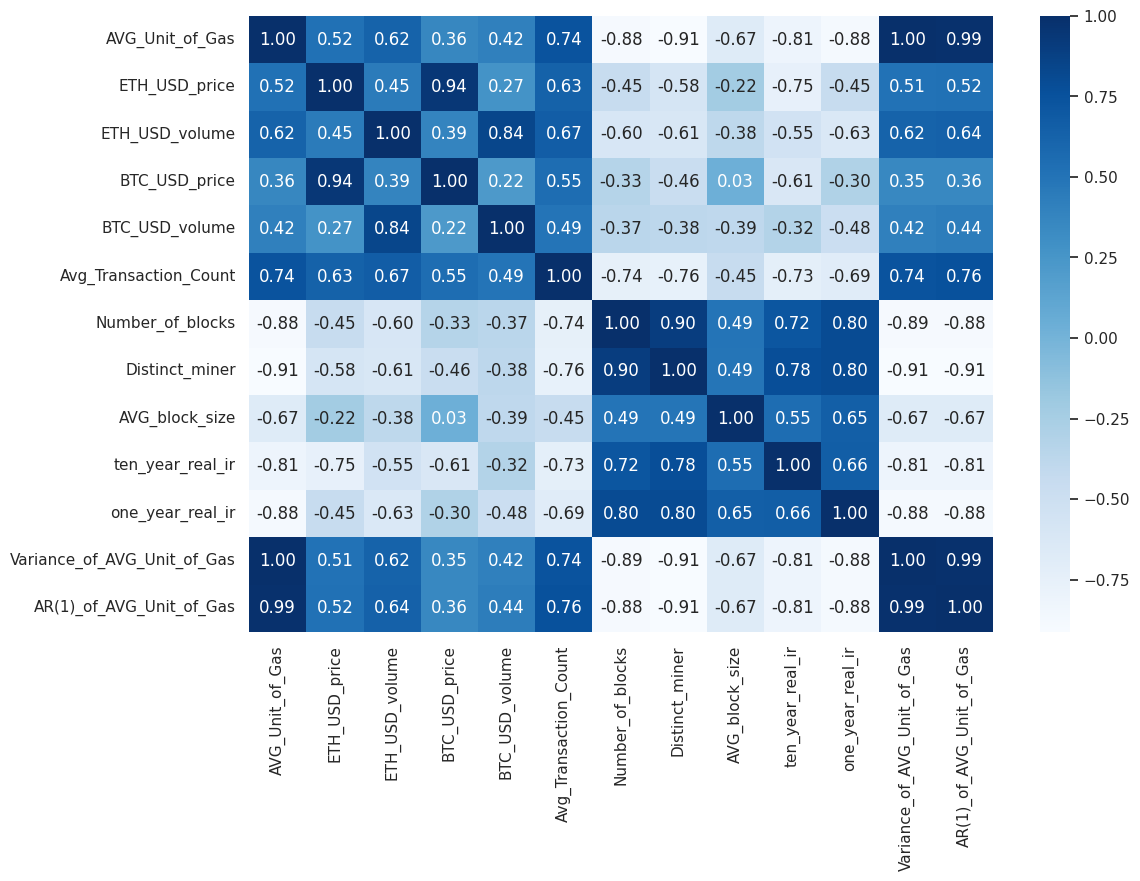

In [ ]:
# plot the correlation coefficient
corr = merge.dropna().corr()
sns.set_theme(rc={'figure.figsize':(12,8)})
sns.heatmap(corr, annot = True, cmap = 'Blues', fmt = ".2f")

In [ ]:
# Fit the model
model_eth = smf.ols(formula = 'AVG_Unit_of_Gas ~ ETH_USD_price + ETH_USD_volume + BTC_USD_price + BTC_USD_volume + Avg_Transaction_Count + Number_of_blocks+ Distinct_miner + AVG_block_size + ten_year_real_ir + one_year_real_ir',\
                    data=merge.dropna())
result_eth = model_eth.fit()
result_eth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        AVG_Unit_of_Gas   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     1277.
Date:                Mon, 06 May 2024   Prob (F-statistic):               0.00
Time:                        09:56:28   Log-Likelihood:                -11282.
No. Observations:                 938   AIC:                         2.259e+04
Df Residuals:                     927   BIC:                         2.264e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1.588e+07   5.94e+04    267.509      0.000    1.58e+07     1.6e+07
ETH_USD_price           -11.2080      6.923     -1.619      0.106     -24.795       2.379
ETH_USD_volume         6.776e-07   4.65e-07      1.457      0.146   -2.35e-07    1.59e-06
BTC_USD_price            -0.2266      0.482     -0.470      0.639      -1.173       0.720
BTC_USD_volume        -3.616e-07   2.35e-07     -1.540      0.124   -8.22e-07    9.91e-08
Avg_Transaction_Count  -120.5519    111.834     -1.078      0.281    -340.029      98.925
Number_of_blocks        -51.6958      8.413     -6.145      0.000     -68.206     -35.185
Distinct_miner         -313.1068     18.729    -16.718      0.000    -349.863    -276.351
AVG_block_size           -0.5726      0.073     -7.867      0.000      -0.716      -0.430
ten_year_real_ir      -5.232e+04   4536.173    -11.534      0.000   -6.12e+04   -4.34e+04
one_year_real_ir      -1.306e+04    943.045    -13.845      0.000   -1.49e+04   -1.12e+04
==============================================================================
Omnibus:                       56.838   Durbin-Watson:                   0.396
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.889
Skew:                           0.449   Prob(JB):                     1.51e-21
Kurtosis:                       4.284   Cond. No.                     1.44e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.44e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Drop ETH_USD_volume,BTC_USD_price,BTC_USD_volume,Avg_Transaction_count
# ReFit the model
model_eth = smf.ols(formula = 'AVG_Unit_of_Gas ~ ETH_USD_price + Number_of_blocks+ Distinct_miner + AVG_block_size + ten_year_real_ir + one_year_real_ir',\
                    data=merge.dropna())
result_eth = model_eth.fit()
result_eth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        AVG_Unit_of_Gas   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     2126.
Date:                Mon, 06 May 2024   Prob (F-statistic):               0.00
Time:                        08:30:38   Log-Likelihood:                -11284.
No. Observations:                 938   AIC:                         2.258e+04
Df Residuals:                     931   BIC:                         2.262e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.586e+07   5.01e+04    316.313      0.000    1.58e+07     1.6e+07
ETH_USD_price      -15.3430      2.555     -6.005      0.000     -20.357     -10.329
Number_of_blocks   -51.5168      8.056     -6.395      0.000     -67.327     -35.706
Distinct_miner    -312.5999     18.670    -16.744      0.000    -349.239    -275.961
AVG_block_size      -0.5633      0.053    -10.702      0.000      -0.667      -0.460
ten_year_real_ir -5.366e+04   4399.142    -12.197      0.000   -6.23e+04    -4.5e+04
one_year_real_ir -1.293e+04    910.997    -14.192      0.000   -1.47e+04   -1.11e+04
==============================================================================
Omnibus:                       56.293   Durbin-Watson:                   0.408
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               97.103
Skew:                           0.438   Prob(JB):                     8.21e-22
Kurtosis:                       4.310   Cond. No.                     4.32e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.32e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# To fix the serial correlation(DW = 0.408), introduce AR(1) term
eth_ar1 = s.tsa.ar_model.AutoReg(merge['AVG_Unit_of_Gas'],lags=1).fit()
eth_ar1_coef = eth_ar1.params[0]
ar1_terms = eth_ar1.predict()
ar1_terms

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2021-08-06             NaN
2021-08-07    1.547284e+07
2021-08-08    1.549888e+07
2021-08-09    1.547057e+07
2021-08-10    1.547119e+07
                  ...     
2024-02-25    1.516664e+07
2024-02-26    1.517375e+07
2024-02-27    1.515504e+07
2024-02-28    1.515888e+07
2024-02-29    1.514894e+07
Freq: D, Length: 938, dtype: float64

In [ ]:
# Add AR(1) term in the dataframe
merge['AR1_terms_AVG_Unit_of_Gas'] = ar1_terms

In [ ]:
# ReFit the model
model_eth = smf.ols(formula = 'AVG_Unit_of_Gas ~ ETH_USD_price + Number_of_blocks+ Distinct_miner + AVG_block_size + ten_year_real_ir + one_year_real_ir + AR1_terms_AVG_Unit_of_Gas',\
                    data=merge.dropna())
result_eth = model_eth.fit()
result_eth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        AVG_Unit_of_Gas   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     6172.
Date:                Mon, 06 May 2024   Prob (F-statistic):               0.00
Time:                        08:38:44   Log-Likelihood:                -10722.
No. Observations:                 937   AIC:                         2.146e+04
Df Residuals:                     929   BIC:                         2.150e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  2.763e+06   2.89e+05      9.571      0.000     2.2e+06    3.33e+06
ETH_USD_price                -2.6599      1.451     -1.834      0.067      -5.507       0.187
Number_of_blocks             -8.2193      4.585     -1.793      0.073     -17.217       0.778
Distinct_miner              -67.9434     11.692     -5.811      0.000     -90.888     -44.998
AVG_block_size               -0.1082      0.031     -3.495      0.000      -0.169      -0.047
ten_year_real_ir          -9228.4330   2643.060     -3.492      0.001   -1.44e+04   -4041.372
one_year_real_ir          -1979.6766    561.051     -3.529      0.000   -3080.750    -878.603
AR1_terms_AVG_Unit_of_Gas     0.8258      0.018     45.591      0.000       0.790       0.861
==============================================================================
Omnibus:                       62.659   Durbin-Watson:                   2.360
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              268.776
Skew:                           0.043   Prob(JB):                     4.32e-59
Kurtosis:                       5.622   Cond. No.                     5.95e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.95e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Drop Eth_USD_price and Number_of_blocks
# ReFit the model
model_eth = smf.ols(formula = 'AVG_Unit_of_Gas ~ Distinct_miner + AVG_block_size + ten_year_real_ir + one_year_real_ir + AR1_terms_AVG_Unit_of_Gas',\
                    data=merge.dropna())
result_eth = model_eth.fit()
result_eth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        AVG_Unit_of_Gas   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     8576.
Date:                Mon, 06 May 2024   Prob (F-statistic):               0.00
Time:                        08:38:49   Log-Likelihood:                -10727.
No. Observations:                 937   AIC:                         2.147e+04
Df Residuals:                     931   BIC:                         2.149e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  2.429e+06   2.66e+05      9.133      0.000    1.91e+06    2.95e+06
Distinct_miner              -74.0632     10.269     -7.213      0.000     -94.215     -53.911
AVG_block_size               -0.1143      0.030     -3.858      0.000      -0.172      -0.056
ten_year_real_ir          -5648.6290   1930.601     -2.926      0.004   -9437.462   -1859.795
one_year_real_ir          -1930.0242    543.136     -3.553      0.000   -2995.937    -864.111
AR1_terms_AVG_Unit_of_Gas     0.8435      0.017     49.111      0.000       0.810       0.877
==============================================================================
Omnibus:                       64.776   Durbin-Watson:                   2.383
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              281.724
Skew:                           0.080   Prob(JB):                     6.67e-62
Kurtosis:                       5.682   Cond. No.                     5.47e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.47e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Drop Interest rate
# ReFit the model
model_eth = smf.ols(formula = 'AVG_Unit_of_Gas ~ Distinct_miner + AVG_block_size + AR1_terms_AVG_Unit_of_Gas',\
                    data=merge.dropna())
result_eth = model_eth.fit()
result_eth.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        AVG_Unit_of_Gas   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Mon, 06 May 2024   Prob (F-statistic):               0.00
Time:                        08:39:12   Log-Likelihood:                -10735.
No. Observations:                 937   AIC:                         2.148e+04
Df Residuals:                     933   BIC:                         2.150e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  1.855e+06    2.3e+05      8.068      0.000     1.4e+06    2.31e+06
Distinct_miner              -83.6505     10.051     -8.323      0.000    -103.375     -63.926
AVG_block_size               -0.1442      0.029     -4.979      0.000      -0.201      -0.087
AR1_terms_AVG_Unit_of_Gas     0.8810      0.015     59.608      0.000       0.852       0.910
==============================================================================
Omnibus:                       61.233   Durbin-Watson:                   2.431
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              255.612
Skew:                          -0.053   Prob(JB):                     3.12e-56
Kurtosis:                       5.557   Cond. No.                     4.69e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.69e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Check multicollinearity
# If VIF <10, there is no severe collinearity
# AR(1) and target variable is correlated, so ignore the final result
X = result_eth.model.exog
vif = [variance_inflation_factor(X,i) for i in range(1,X.shape[1])]
vif

[7.126689547391958,
 2.2306267087780896,
 3.18865360089865,
 4.739447208420019,
 12.621095460029201]

Now we have four features
- distinct number of miners
- Average block size
- 1-year real interest rate
- 10-year real interest rate
- AR(1) of AVG_Unit_of_gas

In [ ]:
features = pd.DataFrame(index = (eth['date']))
features['AVG_Unit_of_Gas'] = eth['avg_daily_gas_used'].values
features['Distinct_miner'] = eth['distinct_miner'].values
features['AVG_block_size'] = eth['avg_block_size'].values
features['ten_year_real_ir'] = eth['10_year_real_interest_rate'].values
features['one_year_real_ir'] = eth['1_year_real_interest_rate'].values
features['AR1_terms_AVG_Unit_of_Gas'] = ar1_terms

### 4.Simple ARIMA model (Only use gas_used)

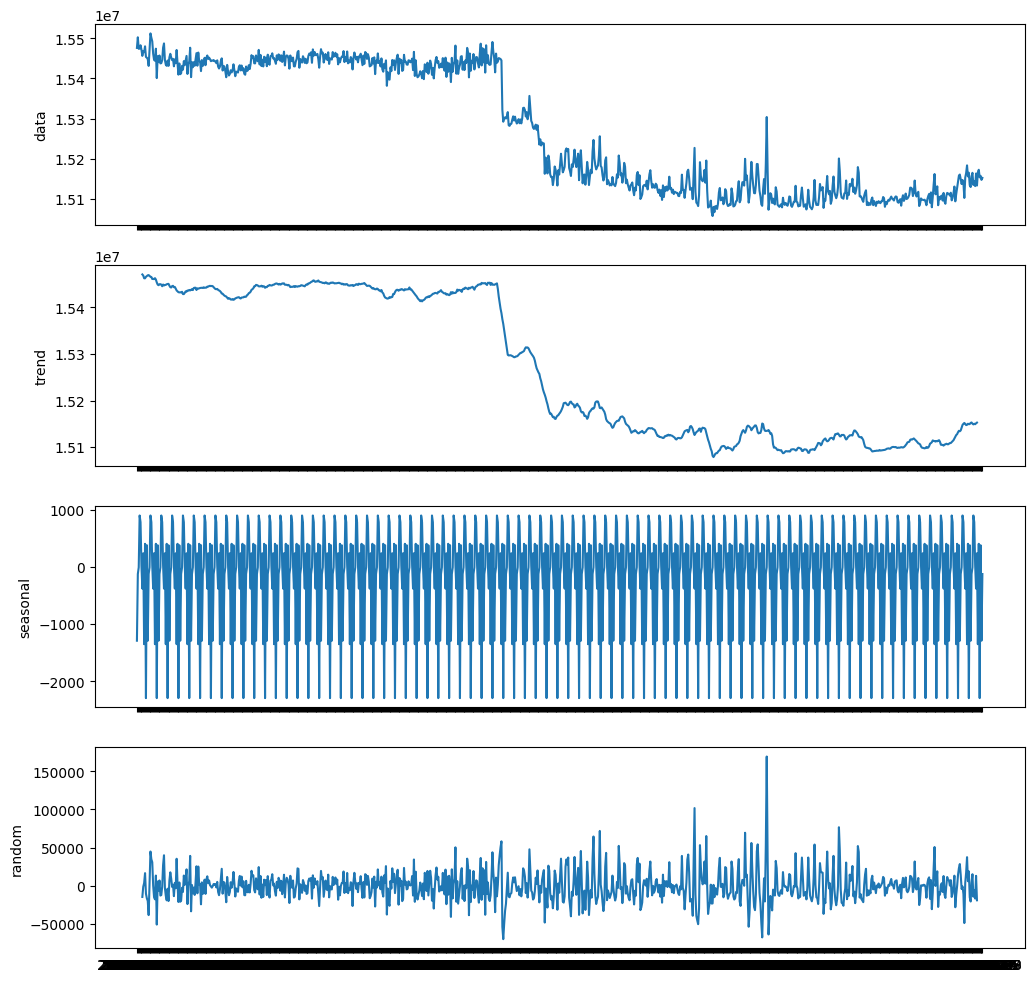

In [ ]:
# Decompose data (trend * seasonality * randomness)
utils.decomposed_plot(arima.decompose(features['AVG_Unit_of_Gas'],'additive',m=12),
                      figure_kwargs = {'figsize': (12, 12)} )

/usr/local/lib/python3.10/dist-packages/pmdarima/utils/visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


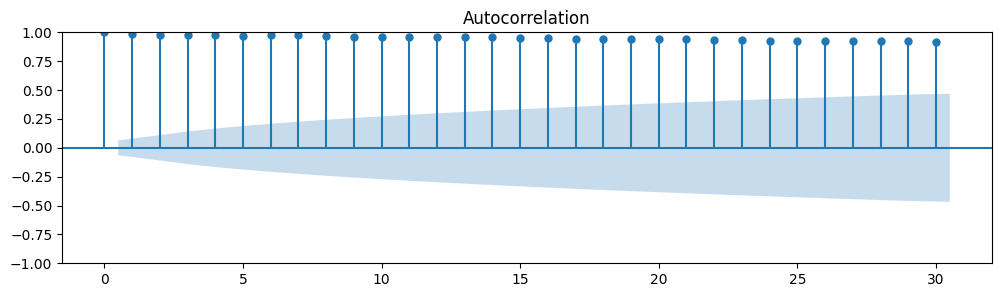

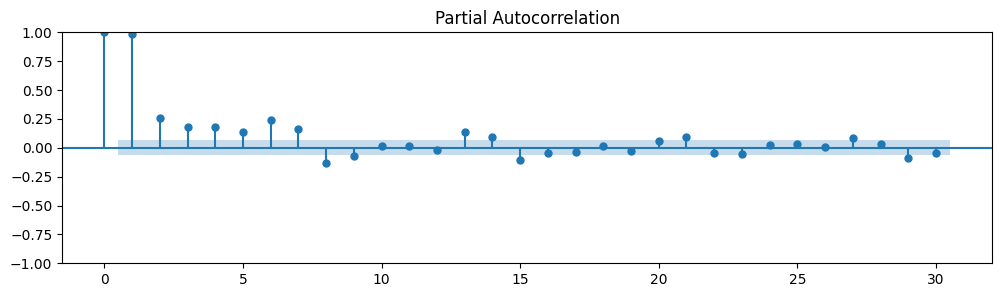

In [ ]:
plt.rcParams['figure.figsize'] = [12, 3]

# Plot Autocorrelation and Partial Autocorrelation
# Since the data is non-stationary, the graphs are so weired.
utils.plot_acf(features['AVG_Unit_of_Gas'], alpha=.05)
utils.plot_pacf(features['AVG_Unit_of_Gas'], alpha=.05)

In [ ]:
# To chage the data from non-stationary to stationary, let's try to take the difference.
# Check how many times I should take the difference (normal diff and seasonal diff)
print('d =', arima.ndiffs(features['AVG_Unit_of_Gas']))
print('D =', arima.nsdiffs(features['AVG_Unit_of_Gas'],m=7))

d = 1
D = 0


In [ ]:
# Take only one normal diff
avg_gas_used_d1 = features['AVG_Unit_of_Gas'].diff(1).dropna()

/usr/local/lib/python3.10/dist-packages/pmdarima/utils/visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


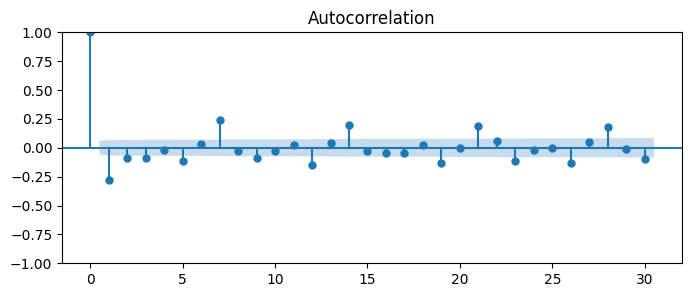

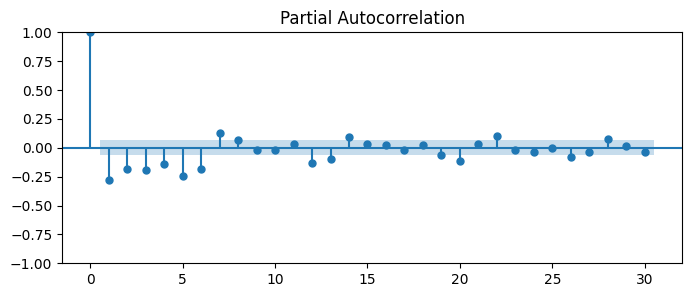

In [ ]:
plt.rcParams['figure.figsize'] = [8, 3]

# Let's re-plot Autocorrelation and Partial Autocorrelation
# now graphs make sense some what
utils.plot_acf(avg_gas_used_d1, alpha=.05)
utils.plot_pacf(avg_gas_used_d1 , alpha=.05)

In [ ]:
# Split data
train, test = model_selection.train_test_split(features['AVG_Unit_of_Gas'], test_size=0.2)

In [ ]:
# Let's create arema model automatically
arima_model = pm.auto_arima(train,
                            seasonal=True,
                            m=7,
                            d=1,
                            trace=True,
                            n_jobs=-1,
                            maxiter=10)

/usr/local/lib/python3.10/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=17315.504, Time=0.82 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17280.976, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=17287.002, Time=0.20 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=17290.771, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=17279.318, Time=0.03 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=17282.395, Time=0.13 sec
 ARIMA(0,1,0)(0,0,1)[7] intercept   : AIC=17282.399, Time=0.33 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=17282.374, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=17285.652, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=17289.453, Time=0.10 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=17300.418, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[7]          
Total fit time: 2.926 seconds


In [ ]:
train_pred = arima_model.predict_in_sample()

test_pred, test_pred_ci = arima_model.predict(
    n_periods=test.shape[0],
    return_conf_int=True
)
print('MSE:')
print(mean_squared_error(test, test_pred))
print('RMSE:')
print(np.sqrt(mean_squared_error(test, test_pred)))
print('MAE:')
print(mean_absolute_error(test, test_pred))
print('MAPE:')
print(mean_absolute_percentage_error(test, test_pred))
print('Out-of-R2:')
print(r2_score(test, test_pred))

MSE:
1771782706.7641206
RMSE:
42092.549302271065
MAE:
34272.23228723337
MAPE:
0.0022647967029143417
Out-of-R2:
-1.9522307740447729


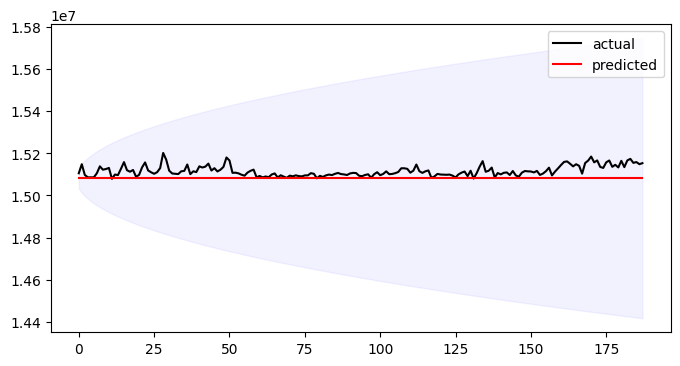

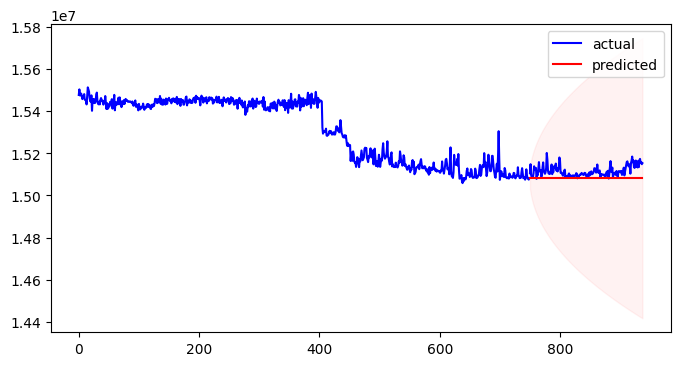

In [ ]:
plt.rcParams['figure.figsize'] = [8, 4]

preds, conf_int95 = arima_model.predict(n_periods=test.shape[0], return_conf_int=True,
                                       alpha=0.05)


# Check the difference between predicted data and actual
x_axis = np.arange(preds.shape[0])
plt.plot(x_axis,test,label="actual",color='black')
plt.plot(x_axis,preds,label="predicted",color='red')
plt.fill_between(x_axis[-preds.shape[0]:],
                 conf_int95[:, 0], conf_int95[:, 1],
                 alpha=0.05, color='b')
plt.legend()
plt.show()

x_axis = np.arange(train.shape[0] + preds.shape[0])
plt.plot(x_axis[:train.shape[0]],train,color='b',label="actual")
plt.plot(x_axis[train.shape[0]:],test,color='b')
plt.plot(x_axis[train.shape[0]:],preds,color='red',label="predicted")
plt.fill_between(x_axis[-preds.shape[0]:],
                 conf_int95[:, 0], conf_int95[:, 1],
                 alpha=0.05,color='red')
plt.legend()
plt.show()

### 5.Vector AutoRegressive model (use multiple AutoRegressive of each feature)

Text(0.5, 1.0, 'AVG_Unit_of_Gas_diff')

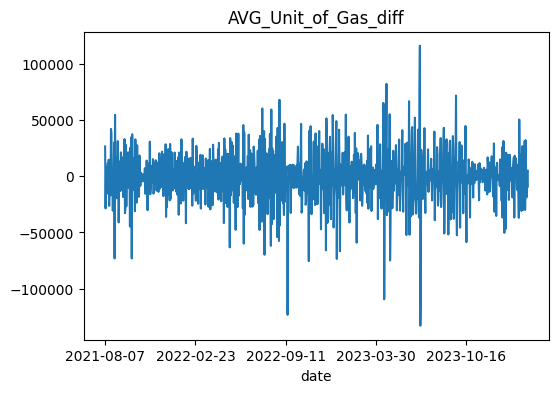

In [ ]:
plt.rcParams['figure.figsize'] = [6, 4]
features['AVG_Unit_of_Gas'].diff().dropna().plot()
plt.title('AVG_Unit_of_Gas_diff')

Text(0.5, 1.0, 'Distinct_miner')

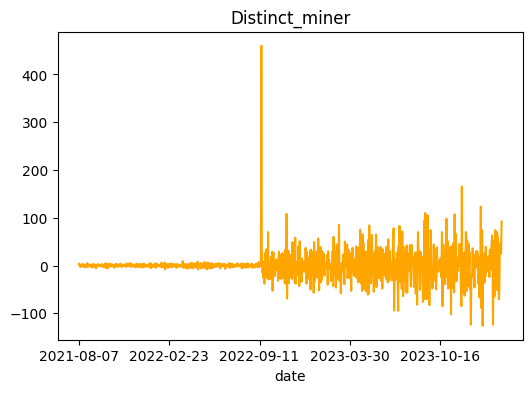

In [ ]:
features['Distinct_miner'].diff().dropna().plot(color = 'orange')
plt.title('Distinct_miner')

Text(0.5, 1.0, 'AVG_block_size')

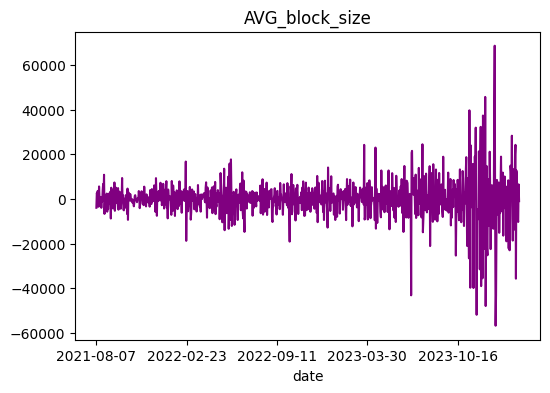

In [ ]:
features['AVG_block_size'].diff().dropna().plot(color = 'purple')
plt.title('AVG_block_size')

Text(0.5, 1.0, 'ten_year_real_ir')

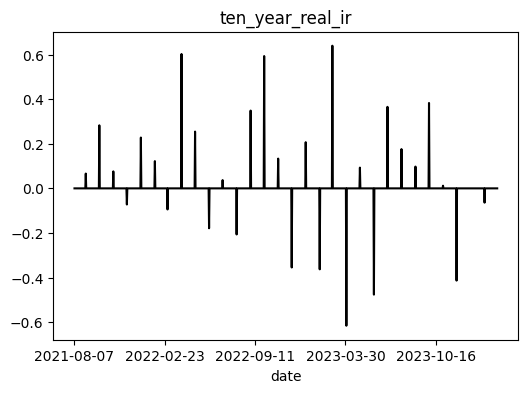

In [ ]:
features['ten_year_real_ir'].diff().dropna().plot(color = 'black')
plt.title('ten_year_real_ir')

Text(0.5, 1.0, 'one_year_real_ir')

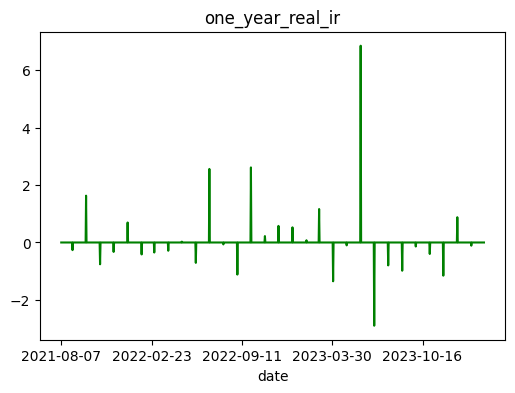

In [ ]:
features['one_year_real_ir'].diff().dropna().plot(color = 'green')
plt.title('one_year_real_ir')

Text(0.5, 1.0, 'AR1_terms_AVG_Unit_of_Gas')

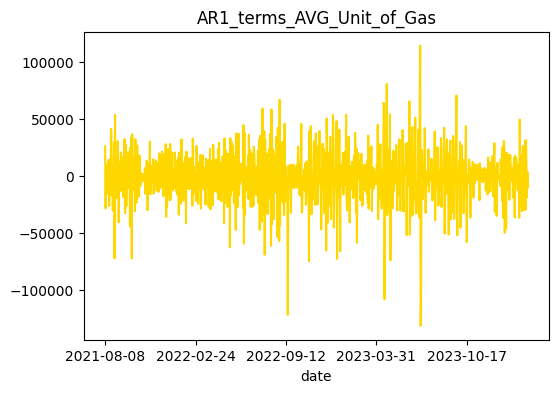

In [ ]:
features['AR1_terms_AVG_Unit_of_Gas'].diff().dropna().plot(color = 'gold')
plt.title('AR1_terms_AVG_Unit_of_Gas')

In [ ]:
# Drop Interest rate since there are many zero due to taking difference
features_without_ir = features.drop(['ten_year_real_ir','one_year_real_ir'],axis=1)

In [ ]:
# Test split
train, test = model_selection.train_test_split(features_without_ir.dropna(), test_size=0.2)
print(train.shape)
print(test.shape)

(749, 4)
(188, 4)


In [ ]:
var_model = VAR(train.diff().dropna())

lag_order = var_model.select_order(maxlags=50)
print(lag_order.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        64.23       64.25   7.828e+27       64.24
1        1.882       2.012       6.565       1.932
2        1.593       1.828       4.920       1.684
3        1.440      1.779*       4.223       1.571
4        1.372       1.815       3.944      1.544*
5        1.333       1.880       3.792       1.545
6       1.303*       1.954      3.679*       1.555
7        1.327       2.083       3.771       1.619
8        1.339       2.199       3.815       1.671
9        1.444       2.408       4.240       1.817
10       2.269       3.338       9.674       2.682
11       1.571       2.744       4.814       2.024
12       1.535       2.812       4.644       2.028
13       1.526       2.908       4.606       2.060
14       1.529       3.014       4.618       2.103
15       1.645       3.235       5.193       2.260
16       2.086       3.780     

In [ ]:
# Fit the model based on aic
optimal_lag = lag_order.selected_orders['aic']
var_model_fitted = var_model.fit(optimal_lag)

In [ ]:
# Did durbin-watson test
# If each value is between 1.6 and 2.4, this regression is valid
out = durbin_watson(var_model_fitted.resid)

for col, val in zip(train.diff().columns, out):
    print(col, ':', round(val, 2))

AVG_Unit_of_Gas : 2.02
Distinct_miner : 2.01
AVG_block_size : 2.0
AR1_terms_AVG_Unit_of_Gas : 2.05


In [ ]:
forecast_input = test.diff().values[-optimal_lag:]
forecast_span =  188
fc = var_model_fitted.forecast(y=forecast_input, steps=forecast_span)
features_without_ir_forecast = pd.DataFrame(fc, index=features_without_ir.index[-forecast_span:], columns=features_without_ir.columns + '_1d')

In [ ]:
# To transform the first-order difference model to the original scale
def invert_transformation(df_train, df_forecast, second_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:
        # Roll back 2nd Diff
        if second_diff:
            df_fc[str(col)+'_1d'] = (df_train[col].iloc[-1]-df_train[col].iloc[-2]) + df_fc[str(col)+'_2d'].cumsum()
        # Roll back 1st Diff
        df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

df_results = invert_transformation(features_without_ir, features_without_ir_forecast, second_diff=False)

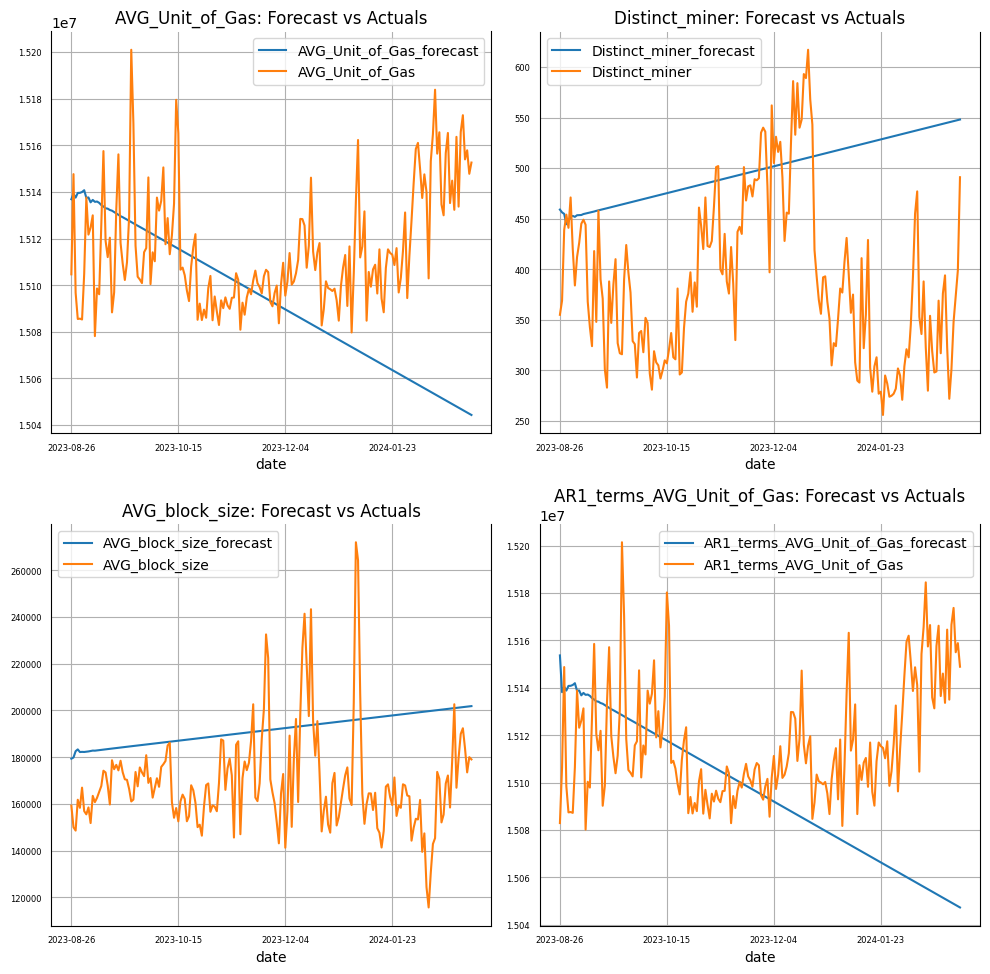

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, dpi=100, figsize=(10,10))
for i, (col,ax) in enumerate(zip(features_without_ir.columns, axes.flatten())):
    #df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
    df_results[col+'_forecast'].plot(legend=True, ax=ax,grid=True)
    features_without_ir[col][-forecast_span:].plot(legend=True, ax=ax,grid=True);
    ax.set_title(col + ": Forecast vs Actuals")
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

In [ ]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    mse = np.mean((forecast - actual)**2)      # MSE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    return({'mape':mape,'mae': mae,'mpe': mpe,'mse':mse ,'rmse':rmse})

print('Forecast Accuracy of: AVG_Unit_of_Gas')
accuracy_prod = forecast_accuracy(df_results['AVG_Unit_of_Gas_forecast'].values, test['AVG_Unit_of_Gas'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('Out-of-R2:')
print(r2_score(df_results['AVG_Unit_of_Gas_forecast'].values, test['AVG_Unit_of_Gas']))

Forecast Accuracy of: AVG_Unit_of_Gas
mape :  0.0023
mae :  34835.897
mpe :  -0.0015
mse :  2259591911.85
rmse :  47535.165
Out-of-R2:
-1.8491649604324967


In [ ]:
len(features.loc['2023-8-26':'2024-2-29','AVG_Unit_of_Gas'])

60

In [ ]:
df_results['AVG_Unit_of_Gas_forecast'].values

array([15136855.64    , 15139185.64    , 15137545.64    , 15139546.64    ,
       15139586.64    , 15139944.64    , 15140712.64    , 15137450.64    ,
       15137609.64    , 15135519.64    , 15136552.030625, 15135723.280625,
       15135863.780625, 15135306.780625, 15134346.030625, 15133722.530625,
       15132963.530625, 15132807.780625, 15132231.561875, 15131932.436875,
       15131337.186875, 15130713.186875, 15130126.686875, 15129586.999375,
       15129145.749375, 15128632.999375, 15128171.999375, 15127616.249375,
       15127069.249375, 15126523.874375, 15126008.749375, 15125506.249375,
       15124995.999375, 15124487.749375, 15123955.499375, 15123426.874375,
       15122899.499375, 15122382.499375, 15121866.749375, 15121350.624375,
       15120833.249375, 15120308.749375, 15119786.124375, 15119263.624375,
       15118744.624375, 15118225.874375, 15117707.124375, 15117187.249375,
       15116665.999375, 15116144.874375, 15115623.874375, 15115104.249375,
       15114584.624375, 1

In [ ]:
features.loc['2023-8-26':'2024-02-29','AVG_Unit_of_Gas']

date
2024-01-01    15112936.19
2024-01-02    15091081.01
2024-01-03    15116626.22
2024-01-04    15079714.47
2024-01-05    15104974.00
2024-01-06    15136215.46
2024-01-07    15162247.19
2024-01-08    15111899.28
2024-01-09    15116572.39
2024-01-10    15131640.65
2024-01-11    15084775.73
2024-01-12    15105663.72
2024-01-13    15099361.19
2024-01-14    15106767.44
2024-01-15    15108762.91
2024-01-16    15096421.11
2024-01-17    15115352.58
2024-01-18    15094271.42
2024-01-19    15088376.83
2024-01-20    15107384.46
2024-01-21    15115363.00
2024-01-22    15113802.35
2024-01-23    15113070.29
2024-01-24    15108633.79
2024-01-25    15115880.87
2024-01-26    15096859.98
2024-01-27    15103124.10
2024-01-28    15114666.56
2024-01-29    15131166.17
2024-01-30    15094465.47
2024-01-31    15112557.37
2024-02-01    15127692.45
2024-02-02    15143809.81
2024-02-03    15158401.46
2024-02-04    15161001.89
2024-02-05    15149806.52
2024-02-06    15137378.01
2024-02-07    15147509.04
2024-02

### 6.KNN regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
features = features.dropna()
y = features['AVG_Unit_of_Gas']
X = features.drop('AVG_Unit_of_Gas',axis=1)
X

,Distinct_miner,AVG_block_size,ten_year_real_ir,one_year_real_ir,AR1_terms_AVG_Unit_of_Gas
date,,,,,
2021-08-07,46,69407.69812,-0.261019,-3.205613,1.547284e+07
2021-08-08,50,72062.30773,-0.261019,-3.205613,1.549888e+07
2021-08-09,48,74105.13420,-0.261019,-3.205613,1.547057e+07
2021-08-10,47,77706.66037,-0.261019,-3.205613,1.547119e+07
2021-08-11,47,74202.64318,-0.261019,-3.205613,1.547937e+07
...,...,...,...,...,...
2024-02-25,301,192390.07300,1.616823,2.395777,1.516664e+07
2024-02-26,348,183794.05560,1.616823,2.395777,1.517375e+07
2024-02-27,374,173489.48910,1.616823,2.395777,1.515504e+07


In [ ]:
X_train, X_val, y_train, y_val = model_selection.train_test_split(X, y,test_size=0.2)
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(749, 5)
(188, 5)
(749,)
(188,)


In [ ]:
# Scale features for regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
# Initialize and train a KNN model
knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_knn = knn_model.predict(X_val_scaled)
mse_knn = mse(y_val, y_pred_knn)
print(f"Mean squared Error of KNN: {mse_knn}")
print('Out-of-sample R2:')
print(r2_score(y_val, y_pred_knn))

Mean squared Error of KNN: 1152303726.592692
Out-of-sample R2:
-0.9200246789327724


### 7.Linearregression

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Initialize and train a KNN model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred_linear = linear_model.predict(X_val_scaled)
mse_linear = mse(y_val, y_pred_linear)
print(f"Mean squared Error of Linear: {mse_linear}")
print('Out-of-sample R2:')
print(r2_score(y_val, y_pred_linear))

Mean squared Error of Linear: 437911983.04723734
Out-of-sample R2:
0.27032969238301685


### 8.LightGBM

In [ ]:
import lightgbm as lgb

In [ ]:
# Initiate the model
lgb_reg = lgb.LGBMRegressor()

# Train LGBMClassifier
lgb_reg_fit = lgb_reg.fit(X_train.values, y_train)

# Predict the response for test dataset
y_pred_lgb = lgb_reg_fit.predict(X_val.values)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 749, number of used features: 5
[LightGBM] [Info] Start training from score 15310203.284379
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [ ]:
# Check classification error
mse_lgb = mse(y_val, y_pred_lgb)
print("Mean Squared Error:", mse_lgb)
print('Out-of-sample R2:')
print(r2_score(y_val, y_pred_lgb))

Mean Squared Error: 401967713.65043736
Out-of-sample R2:
0.3302217874230414


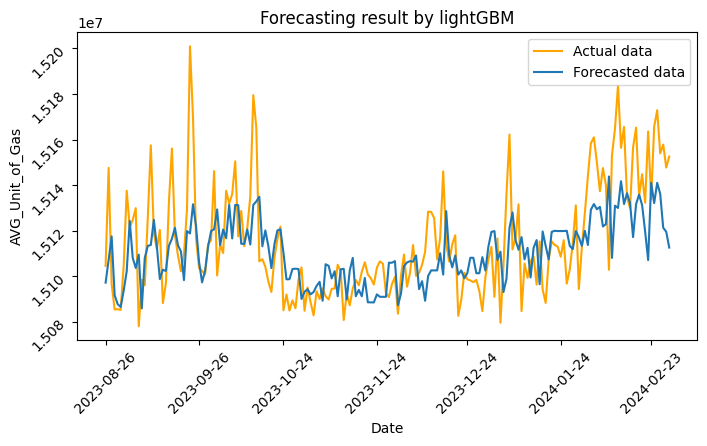

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
plt.plot(y_val, label="Actual data",color='orange')
plt.plot(y_pred_lgb,label="Forecasted data")
ax.set_title('Forecasting result by lightGBM')
ax.set_xlabel('Date')
ax.set_ylabel('AVG_Unit_of_Gas')
plt.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.tick_params(rotation=45)
plt.show()

### 9.XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
# Initiate the model
xgb_reg = xgb.XGBRegressor()

# Train LGBMClassifier
xgb_reg_fit = xgb_reg.fit(X_train.values, y_train)

# Predict the response for test dataset
y_pred_xgb = xgb_reg_fit.predict(X_val.values)

In [ ]:
# Check classification error
mse_xgb = mse(y_val, y_pred_xgb)
print("Mean Squared Error:", mse_xgb)
print('Out-of-sample R2:')
print(r2_score(y_val, y_pred_xgb))

Mean Squared Error: 687673673.9149946
Out-of-sample R2:
-0.14583542038293307


### 10.RandomForest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Initiate the model
rf_reg = RandomForestRegressor()

# Train LGBMClassifier
rf_reg_fit = rf_reg.fit(X_train.values, y_train)

# Predict the response for test dataset
y_pred_rf = rf_reg_fit.predict(X_val.values)

In [ ]:
# Check classification error
mse_rf = mse(y_val, y_pred_rf)
print("Mean Squared Error:", mse_rf)
print('Out-of-sample R2:')
print(r2_score(y_val, y_pred_rf))

Mean Squared Error: 558119858.0114584
Out-of-sample R2:
0.07003346734533489


### 11.Chronos

In [ ]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-2936pio6
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-2936pio6
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 6ae390f2912c6d0521a1d5860f8f2aeb4089ccee
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 2.9 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl 

In [ ]:
# Test split
# Due to Chronos cannot forecast greater than 64 day, so set test_size =64
train, test = model_selection.train_test_split(features_without_ir.dropna(), test_size=64)
print(train.shape)
print(test.shape)

(873, 4)
(64, 4)


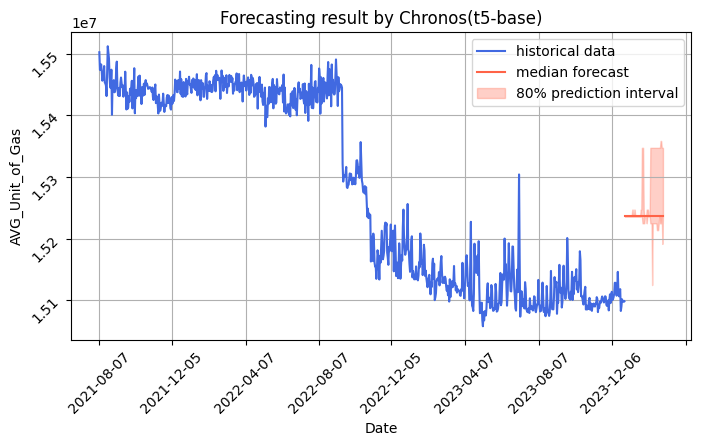

In [ ]:
import torch
from chronos import ChronosPipeline
pipeline = ChronosPipeline.from_pretrained(
  "amazon/chronos-t5-base",
  torch_dtype=torch.bfloat16,
)

# context must be either a 1D tensor, a list of 1D tensors,
# or a left-padded 2D tensor with batch as the first dimension
context = torch.tensor(train['AVG_Unit_of_Gas'])

# Prediction length is limited to 64 due to a current specification
prediction_length = 64
forecast = pipeline.predict(context, prediction_length)  # shape [num_series, num_samples, prediction_length]

# visualize the forecast
forecast_index = range(len(train['AVG_Unit_of_Gas']), len(train['AVG_Unit_of_Gas']) + prediction_length)
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

fig, ax = plt.subplots(figsize=(8,4))
plt.plot(train['AVG_Unit_of_Gas'], color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
ax.set_title('Forecasting result by Chronos(t5-base)')
ax.set_xlabel('Date')
ax.set_ylabel('AVG_Unit_of_Gas')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.tick_params(rotation=45)
plt.show()

In [ ]:
accuracy_prod = forecast_accuracy(pd.Series(forecast[0][0].numpy()), test['AVG_Unit_of_Gas'].values)
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))
print('Out-of-sample R2:')
print(r2_score(pd.Series(forecast[0][0].numpy()), test['AVG_Unit_of_Gas']))

mape :  0.0423
mae :  640875.151
mpe :  0.0423
mse :  643536877640.8616
rmse :  802207.5029
Out-of-sample R2:
-1.5716172823338748


In [ ]:
forecast

tensor([[[15203148.8092, 15203148.8092, 15314936.5612,  ...,
          15314936.5612, 15314936.5612, 15314936.5612],
         [15203148.8092, 15203148.8092, 15203148.8092,  ...,
          15203148.8092, 15314936.5612, 15203148.8092],
         [15203148.8092, 15203148.8092, 15091361.0572,  ...,
          15091361.0572, 15091361.0572, 15091361.0572],
         ...,
         [15203148.8092, 15203148.8092, 15203148.8092,  ...,
          15203148.8092, 15314936.5612, 15203148.8092],
         [15203148.8092, 15203148.8092, 15203148.8092,  ...,
          15203148.8092, 15314936.5612, 15314936.5612],
         [15203148.8092, 15314936.5612, 15203148.8092,  ...,
          15091361.0572, 15091361.0572, 15091361.0572]]], dtype=torch.float64)

## Deep Learning (Pytorch) part

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score



drive.mount('/content/drive')
file_path = "/content/drive/My Drive/ml-003_master_file..csv"
df = pd.read_csv(file_path)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.drop(columns=['date'], inplace=True)

df.head()
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot = True, cmap = 'Blues', fmt = ".2f")
plt.title('Correlation Matrix')
plt.show()
'''
#Split
X = df.drop(columns=['avg_daily_gas_used'])
Y = df['avg_daily_gas_used']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

# Normalize the data using only the training set
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32)
'''

# Prepare features and target
X = df.drop(columns=['avg_daily_gas_used'])
Y = df['avg_daily_gas_used']

# Define split percentages
train_percentage = 0.8
val_percentage = 0.1
test_percentage = 1 - (train_percentage + val_percentage)

# Calculate indices for splitting
train_idx = int(len(df) * train_percentage)
val_idx = train_idx + int(len(df) * val_percentage)

# Split data chronologically
X_train = X.iloc[:train_idx]
Y_train = Y.iloc[:train_idx]
X_val = X.iloc[train_idx:val_idx]
Y_val = Y.iloc[train_idx:val_idx]
X_test = X.iloc[val_idx:]
Y_test = Y.iloc[val_idx:]

# Normalize the data using the training set stats
scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_Y = StandardScaler().fit(Y_train.values.reshape(-1, 1))
Y_train_scaled = scaler_Y.transform(Y_train.values.reshape(-1, 1))
Y_val_scaled = scaler_Y.transform(Y_val.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled.ravel(), dtype=torch.float32)  # Flatten arrays
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_scaled.ravel(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled.ravel(), dtype=torch.float32)

#Time Series Transformer
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
SEQUENCE_SIZE = 10

def to_sequences(seq_size, obs):
    x = []
    y = []
    for i in range(len(obs) - seq_size):
        window = obs[i:(i + seq_size)].numpy()  # Convert tensor to numpy array
        after_window = obs[i + seq_size].numpy()  # Convert tensor to numpy array
        x.append(window)
        y.append(after_window)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

x_train, y_train = to_sequences(SEQUENCE_SIZE, X_train_tensor)
x_test, y_test = to_sequences(SEQUENCE_SIZE, X_test_tensor)


#Setup data loaders for batch
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)
# Define the Transformer model and move it to the appropriate device (CPU or GPU)
# Positional Encoding for Transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

# Model definition using Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim=11, d_model=16, nhead=2, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)  # Adjusted input_dim to match the number of features
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 1)  # Output dimension matches the decoder size

    def forward(self, x):
        x = self.encoder(x.permute(1, 0, 2))  # Permute input to match linear layer expectation
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x.permute(1, 0, 2))  # Permute output to match the expected shape
        return x.squeeze(2)  # Squeeze the last dimension to match the target shape

model = TransformerModel().to(device)

# Train the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5, verbose=True)
epochs = 100
early_stop_count = 0
min_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    train_losses = []
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    if early_stop_count >= 5:
        print("Early stopping!")
        break

import matplotlib.pyplot as plt

# Initialize lists to store loss values for plotting
all_train_losses = []
all_val_losses = []

# Train the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5, verbose=True)
epochs = 100
early_stop_count = 0
min_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    train_losses = []
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    # Calculate and store average loss for the epoch
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    if early_stop_count >= 5:
        print("Early stopping!")
        break


plt.figure(figsize=(10, 5))
plt.plot(all_train_losses, label='Training Loss')
plt.plot(all_val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerModel(nn.Module):
    def __init__(self, input_dim=11, d_model=16, nhead=2, num_layers=2, dropout=0.2):
        super(TransformerModel, self).__init__()
        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.encoder(x.permute(1, 0, 2))
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x.permute(1, 0, 2))
        return x.squeeze(2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransformerModel().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

epochs = 100
min_val_loss = float('inf')
for epoch in range(epochs):
    model.train()
    train_losses, val_losses = [], []
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
        if early_stop_count >= 5:
            print("Early stopping!")
            break

#DNN
class Model(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(Model, self).__init__()
        self.fc_layers = nn.ModuleList([nn.Linear(input_size, hidden_sizes[0])])
        for i in range(len(hidden_sizes) - 1):
            self.fc_layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)

    def forward(self, x):
        for layer in self.fc_layers:
            x = layer(x)
            x = self.relu(x)
        x = self.output_layer(x)
        return x


# initialize the model
input_size = X_train.shape[1]
hidden_size = [64, 32, 16]
output_size = 1
model = Model(input_size, hidden_size, output_size)

# loss func and optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# with l1

def train_model(model, optimizer, loss_function, X_train, Y_train, X_test, Y_test, num_epochs=1000):
    training_loss_history = []
    test_loss_history = []

    for epoch in range(1, num_epochs+1):
        # Training
        model.train()
        optimizer.zero_grad()
        Y_pred_train = model(X_train)
        loss_train = loss_function(Y_pred_train, Y_train)

        # L1 regularization
        l1_lambda = 0.001  # Adjust the lambda parameter for L1 regularization
        l1_regularization = torch.tensor(0.)
        for param in model.parameters():
            l1_regularization += torch.norm(param, 1)
        loss_train += l1_lambda * l1_regularization

        loss_train.backward()
        optimizer.step()
        training_loss_history.append(loss_train.item())

        # Test
        model.eval()
        with torch.no_grad():
            Y_pred_test = model(X_test)
            loss_test = loss_function(Y_pred_test, Y_test)
            test_loss_history.append(loss_test.item())

        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Training Loss: {loss_train.item()}, Test Loss: {loss_test.item()}")

    return training_loss_history, test_loss_history

# Train the model
history_train, history_test = train_model(model, optimizer, loss_function, X_train_tensor, Y_train_tensor, X_test_tensor, Y_test_tensor)

history_df = pd.DataFrame({'train_loss': history_train, 'test_loss': history_test})
history_df.plot()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.show()
import torch
import torch.nn as nn
import torch.optim as optim

class Model(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(Model, self).__init__()
        self.fc_layers = nn.ModuleList([nn.Linear(input_size, hidden_sizes[0])])
        for i in range(1, len(hidden_sizes)):
            self.fc_layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)

    def forward(self, x):
        for layer in self.fc_layers:
            x = self.relu(layer(x))
        x = self.output_layer(x)
        return x

# Assuming X_train_tensor etc. are already defined and are on the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(input_size, hidden_size, output_size).to(device)

# Loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, optimizer, loss_function, X_train, Y_train, X_test, Y_test, num_epochs=1000):
    training_loss_history = []
    test_loss_history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        Y_pred_train = model(X_train)
        loss_train = loss_function(Y_pred_train, Y_train)

        # L1 Regularization
        l1_lambda = 0.001
        l1_regularization = torch.tensor(0., device=device)
        for param in model.parameters():
            l1_regularization += torch.norm(param, 1)
        loss_train += l1_lambda * l1_regularization

        loss_train.backward()
        optimizer.step()
        training_loss_history.append(loss_train.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            Y_pred_test = model(X_test)
            loss_test = loss_function(Y_pred_test, Y_test)
            test_loss_history.append(loss_test.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Training Loss: {loss_train.item()}, Test Loss: {loss_test.item()}")

    return training_loss_history, test_loss_history

# Train the model
history_train, history_test = train_model(model, optimizer, loss_function, X_train_tensor.to(device), Y_train_tensor.to(device), X_test_tensor.to(device), Y_test_tensor.to(device))

history_df = pd.DataFrame({'train_loss': history_train, 'test_loss': history_test})
history_df.plot()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.show()
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Assuming df is your DataFrame loaded elsewhere
X = df.drop(columns=['avg_daily_gas_used'])
Y = df['avg_daily_gas_used']

# Data splitting (assuming chronological or random based on your dataset characteristics)
train_idx = int(len(df) * 0.8)
val_idx = train_idx + int(len(df) * 0.1)

X_train, Y_train = X.iloc[:train_idx], Y.iloc[:train_idx]
X_val, Y_val = X.iloc[train_idx:val_idx], Y.iloc[train_idx:val_idx]
X_test, Y_test = X.iloc[val_idx:], Y.iloc[val_idx:]

# Data normalization
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Assuming target scaling is necessary
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train.values.reshape(-1, 1))
Y_val_scaled = scaler_Y.transform(Y_val.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

# Converting to tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train_scaled.ravel(), dtype=torch.float32).to(device)

# Model, loss, and optimizer
model = Model(X_train_tensor.shape[1], [64, 32, 16], 1).to(device)
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop (simplified for clarity)
def train_model(model, optimizer, loss_function, X_train, Y_train, num_epochs=1000):
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        Y_pred_train = model(X_train)
        loss_train = loss_function(Y_pred_train, Y_train)
        loss_train.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f'Epoch {epoch}: Training Loss: {loss_train.item()}')

train_model(model, optimizer, loss_function, X_train_tensor, Y_train_tensor)


class Model(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.5):
        super(Model, self).__init__()
        self.fc_layers = nn.ModuleList()
        self.dropouts = nn.ModuleList()

        # Input layer
        self.fc_layers.append(nn.Linear(input_size, hidden_sizes[0]))
        self.dropouts.append(nn.Dropout(dropout_rate))

        # Hidden layers
        for i in range(1, len(hidden_sizes)):
            self.fc_layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.dropouts.append(nn.Dropout(dropout_rate))

        # Output layer
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)

    def forward(self, x):
        for layer, dropout in zip(self.fc_layers, self.dropouts):
            x = nn.ReLU()(dropout(layer(x)))
        x = self.output_layer(x)
        return x

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)  # Adding L2 regularization

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, optimizer, loss_function, X_train, Y_train, X_test, Y_test, num_epochs=1000):
    training_loss_history = []
    test_loss_history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        Y_pred_train = model(X_train)
        loss_train = loss_function(Y_pred_train, Y_train)

        # L1 Regularization
        l1_lambda = 0.001
        l1_regularization = torch.tensor(0., device=device)
        for param in model.parameters():
            l1_regularization += torch.norm(param, 1)
        loss_train += l1_lambda * l1_regularization

        loss_train.backward()
        optimizer.step()
        training_loss_history.append(loss_train.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            Y_pred_test = model(X_test)
            loss_test = loss_function(Y_pred_test, Y_test)
            test_loss_history.append(loss_test.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Training Loss: {loss_train.item()}, Test Loss: {loss_test.item()}")

    return training_loss_history, test_loss_history

# Train the model
history_train, history_test = train_model(model, optimizer, loss_function, X_train_tensor.to(device), Y_train_tensor.to(device), X_test_tensor.to(device), Y_test_tensor.to(device))

# use different subset of variables?

# Prepare features and target
X = df[['distinct_block_number', 'avg_block_size','1_year_real_interest_rate', '10_year_real_interest_rate','daily_gas_used_var']]
Y = df['avg_daily_gas_used']

# Define split percentages
train_percentage = 0.8
val_percentage = 0.1
test_percentage = 1 - (train_percentage + val_percentage)

# Calculate indices for splitting
train_idx = int(len(df) * train_percentage)
val_idx = train_idx + int(len(df) * val_percentage)

# Split data chronologically
X_train = X.iloc[:train_idx]
Y_train = Y.iloc[:train_idx]
X_val = X.iloc[train_idx:val_idx]
Y_val = Y.iloc[train_idx:val_idx]
X_test = X.iloc[val_idx:]
Y_test = Y.iloc[val_idx:]

# Normalize the data using the training set stats
scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_Y = StandardScaler().fit(Y_train.values.reshape(-1, 1))
Y_train_scaled = scaler_Y.transform(Y_train.values.reshape(-1, 1))
Y_val_scaled = scaler_Y.transform(Y_val.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled.ravel(), dtype=torch.float32)  # Flatten arrays
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_scaled.ravel(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled.ravel(), dtype=torch.float32)

# initialize the model
input_size = X_train.shape[1]
hidden_size = [64, 32, 16]
output_size = 1
model = Model(input_size, hidden_size, output_size)

# loss func and optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


import torch
import torch.nn as nn
import torch.optim as optim

class Model(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(Model, self).__init__()
        self.fc_layers = nn.ModuleList([nn.Linear(input_size, hidden_sizes[0])])
        for i in range(1, len(hidden_sizes)):
            self.fc_layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_sizes[-1], output_size)

    def forward(self, x):
        for layer in self.fc_layers:
            x = self.relu(layer(x))
        x = self.output_layer(x)
        return x

# Assuming X_train_tensor etc. are already defined and are on the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(input_size, hidden_size, output_size).to(device)

# Loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, optimizer, loss_function, X_train, Y_train, X_test, Y_test, num_epochs=1000):
    training_loss_history = []
    test_loss_history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        Y_pred_train = model(X_train)
        loss_train = loss_function(Y_pred_train, Y_train)

        # L1 Regularization
        l1_lambda = 0.001
        l1_regularization = torch.tensor(0., device=device)
        for param in model.parameters():
            l1_regularization += torch.norm(param, 1)
        loss_train += l1_lambda * l1_regularization

        loss_train.backward()
        optimizer.step()
        training_loss_history.append(loss_train.item())

        # Evaluation
        model.eval()
        with torch.no_grad():
            Y_pred_test = model(X_test)
            loss_test = loss_function(Y_pred_test, Y_test)
            test_loss_history.append(loss_test.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Training Loss: {loss_train.item()}, Test Loss: {loss_test.item()}")

    return training_loss_history, test_loss_history

# Train the model
history_train, history_test = train_model(model, optimizer, loss_function, X_train_tensor.to(device), Y_train_tensor.to(device), X_test_tensor.to(device), Y_test_tensor.to(device))

history_df = pd.DataFrame({'train_loss': history_train, 'test_loss': history_test})
history_df.plot()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.show()
#RNN - LSTM
X = df.drop(columns=['avg_daily_gas_used'])
Y = df['avg_daily_gas_used']

# train/test and validation percentage
train_percentage = 0.8
val_percentage = 0.1

# sizes
train_size = int(len(df) * train_percentage)
val_size = int(len(df) * val_percentage)
test_size = len(df) - train_size - val_size

# splits
X_train = X[:train_size]
Y_train = Y[:train_size]

X_val = X[train_size:train_size + val_size]
Y_val = Y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
Y_test = Y[train_size + val_size:]

# normalize the data (use the mean and std the training set)
X_train_mean, X_train_std = X_train.mean(), X_train.std()
Y_train_mean, Y_train_std = Y_train.mean(), Y_train.std()

X_train = (X_train - X_train_mean) / X_train_std
Y_train = (Y_train - Y_train_mean) / Y_train_std

X_val = (X_val - X_train_mean) / X_train_std
Y_val = (Y_val - Y_train_mean) / Y_train_std

X_test = (X_test - X_train_mean) / X_train_std
Y_test = (Y_test - Y_train_mean) / Y_train_std

# convert to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32)
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Define hyperparameters
input_size = X_train_tensor.shape[1]  # Number of features
hidden_size = 20  # Number of hidden units
output_size = 1  # Single output for regression

# Create the model
model = LSTM(input_size, hidden_size, output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adjust learning rate as needed

# Print model architecture
print(model)


# Reshape X_train_tensor to match the expected input shape (batch_size, sequence_length, input_size)
batch_size = X_train_tensor.shape[0]
sequence_length = 1 # Since it seems like you're using daily data, sequence length is 1
input_size = X_train_tensor.shape[1]

# Reshape the tensors assuming each sample is an independent sequence
X_train_tensor = X_train_tensor.view(X_train_tensor.shape[0], 1, X_train_tensor.shape[1])
X_val_tensor = X_val_tensor.view(X_val_tensor.shape[0], 1, X_val_tensor.shape[1])
X_test_tensor = X_test_tensor.view(X_test_tensor.shape[0], 1, X_test_tensor.shape[1])


import torch
import matplotlib.pyplot as plt

# Assume model, optimizer, and criterion are already defined and initialized

num_epochs = 200
train_losses = []
val_losses = []

# Move the model to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs.squeeze(), Y_train_tensor.to(device))
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    # Record training loss
    train_losses.append(loss.item())
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

    # Validation step
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs.squeeze(), Y_val_tensor.to(device))
        val_losses.append(val_loss.item())
        print(f'Validation Loss: {val_loss.item()}')

# Optional: Evaluate the model on the test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    test_loss = criterion(test_outputs.squeeze(), Y_test_tensor.to(device))
    print(f'Test Loss: {test_loss.item()}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

import torch
import matplotlib.pyplot as plt

# Assume model, optimizer, and criterion are already defined and initialized

num_epochs = 200
train_losses = []
val_losses = []

# Move the model to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs.squeeze(), Y_train_tensor.to(device))
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    # Record training loss
    train_losses.append(loss.item())
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

    # Validation step
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs.squeeze(), Y_val_tensor.to(device))
        val_losses.append(val_loss.item())
        print(f'Validation Loss: {val_loss.item()}')

# Optional: Evaluate the model on the test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    test_loss = criterion(test_outputs.squeeze(), Y_test_tensor.to(device))
    print(f'Test Loss: {test_loss.item()}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

import torch
import matplotlib.pyplot as plt

# Assume model, optimizer, and criterion are already defined and initialized

num_epochs = 1000
train_losses = []
val_losses = []

# Move the model to the appropriate device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    optimizer.zero_grad()  # Clear gradients
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs.squeeze(), Y_train_tensor.to(device))
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    # Record training loss
    train_losses.append(loss.item())
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

    # Validation step
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs.squeeze(), Y_val_tensor.to(device))
        val_losses.append(val_loss.item())
        print(f'Validation Loss: {val_loss.item()}')

# Optional: Evaluate the model on the test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    test_loss = criterion(test_outputs.squeeze(), Y_test_tensor.to(device))
    print(f'Test Loss: {test_loss.item()}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#LASSO RIDGE
from sklearn.pipeline import Pipeline

def backtest(X, Y, model, min_train_size, retrain):
    mse_scores = []
    for i in range(min_train_size, len(X), retrain):
        X_train = X.iloc[:i]
        Y_train = Y.iloc[:i]
        X_test = X.iloc[i:i + retrain]
        Y_test = Y.iloc[i:i + retrain]

        # Use a pipeline to ensure scaling is fit only on training data
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipeline.fit(X_train, Y_train)
        Y_pred = pipeline.predict(X_test)
        mse = mean_squared_error(Y_test, Y_pred)
        mse_scores.append(mse)

    mean_mse = sum(mse_scores) / len(mse_scores)
    return mean_mse

# Define models in a pipeline
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001, max_iter=10000))
])
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.001, max_iter=10000))
])

# Backtesting
mean_mse_lasso = backtest(X, Y, lasso_model, min_train_size, retrain)
print("Mean MSE for Lasso Regression:", mean_mse_lasso)

mean_mse_ridge = backtest(X, Y, ridge_model, min_train_size, retrain)
print("Mean MSE for Ridge Regression:", mean_mse_ridge)

# out of sample r squared
def backtest(X, Y, model, roll_forward_days, min_train_size, retrain):
    r2_scores = []
    for i in range(min_train_size, len(X), retrain):
        X_train = X.iloc[:i]
        Y_train = Y.iloc[:i]
        X_test = X.iloc[i:i+roll_forward_days]
        Y_test = Y.iloc[i:i+roll_forward_days]

        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)
        r2 = r2_score(Y_test, Y_pred)
        r2_scores.append(r2)

        # retrain
        X_retrain = X.iloc[i-min_train_size:i+retrain]
        Y_retrain = Y.iloc[i-min_train_size:i+retrain]
        model.fit(X_retrain, Y_retrain)

    mean_r2 = sum(r2_scores) / len(r2_scores)
    return mean_r2

min_train_size = 20  # Adjustable
retrain = 10  # Adjustable
roll_forward_days = 2  # Adjustable

# Lasso
lasso_model = Lasso(alpha=0.001)
mean_r2_lasso = backtest(X, Y, lasso_model, roll_forward_days, min_train_size, retrain)
print("Mean R-squared for Lasso Regression:", mean_r2_lasso)

# Ridge
ridge_model = Ridge(alpha=0.001)
mean_r2_ridge = backtest(X, Y, ridge_model, roll_forward_days, min_train_size, retrain)
print("Mean R-squared for Ridge Regression:", mean_r2_ridge)

from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def backtest(X, Y, model, roll_forward_days, min_train_size, retrain):
    r2_scores = []
    for i in range(min_train_size, len(X) - roll_forward_days + 1, retrain):
        X_train = X.iloc[:i]
        Y_train = Y.iloc[:i]
        X_test = X.iloc[i:i + roll_forward_days]
        Y_test = Y.iloc[i:i + roll_forward_days]

        # Fit model and predict
        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)
        r2 = r2_score(Y_test, Y_pred)
        r2_scores.append(r2)

    mean_r2 = sum(r2_scores) / len(r2_scores)
    return mean_r2

# Models in a pipeline with feature scaling
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001))
])
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=0.001))
])

min_train_size = 20
retrain = 10
roll_forward_days = 2

# Backtesting
mean_r2_lasso = backtest(X, Y, lasso_model, roll_forward_days, min_train_size, retrain)
print("Mean R-squared for Lasso Regression:", mean_r2_lasso)

mean_r2_ridge = backtest(X, Y, ridge_model, roll_forward_days, min_train_size, retrain)
print("Mean R-squared for Ridge Regression:", mean_r2_ridge)

# Calculate R-squared (coefficient of determination) for Lasso model on validation set
lasso_val_r_squared = lasso_model.score(X_val, Y_val)

# Calculate R-squared (coefficient of determination) for Ridge model on validation set
ridge_val_r_squared = ridge_model.score(X_val, Y_val)

print("Out-of-Sample R^2 for Lasso:", lasso_val_r_squared)
print("Out-of-Sample R^2 for Ridge:", ridge_val_r_squared)

# XGB
# Initialize XGBoost regressor
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the model
xgb_regressor.fit(X_train, Y_train)

# Evaluate on the test set
Y_pred_test_xgb = xgb_regressor.predict(X_test)
test_loss_xgb = mean_squared_error(Y_test, Y_pred_test_xgb)
print(f"XGBoost Test Loss: {test_loss_xgb:.4f}")

# Assuming you have already calculated test_loss for the DNN model
# print(f"DNN Test Loss: {test_loss.item():.4f}")
print(f"XGBoost Test Loss: {test_loss_xgb:.4f}")

# define the parameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 6, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# grid search object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2) # increase cv?

# search
grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

# evaluate the best parameters
best_model = grid_search.best_estimator_
Y_pred_test_best = best_model.predict(X_test)
test_loss_best = mean_squared_error(Y_test, Y_pred_test_best)
print(f"Test Loss with Best Parameters: {test_loss_best}")

xgb.get_booster().get_score()
xgb.plot_importance(xgb_regressor)

# DNN - 2
# Prepare features and target
X = df.drop(columns=['avg_daily_gas_used'])
Y = df['avg_daily_gas_used']

# Define split percentages
train_percentage = 0.8
val_percentage = 0.1
test_percentage = 1 - (train_percentage + val_percentage)

# Calculate indices for splitting
train_idx = int(len(df) * train_percentage)
val_idx = train_idx + int(len(df) * val_percentage)

# Split data chronologically
X_train = X.iloc[:train_idx]
Y_train = Y.iloc[:train_idx]
X_val = X.iloc[train_idx:val_idx]
Y_val = Y.iloc[train_idx:val_idx]
X_test = X.iloc[val_idx:]
Y_test = Y.iloc[val_idx:]

# Normalize the data using the training set stats
scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_Y = StandardScaler().fit(Y_train.values.reshape(-1, 1))
Y_train_scaled = scaler_Y.transform(Y_train.values.reshape(-1, 1))
Y_val_scaled = scaler_Y.transform(Y_val.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled.ravel(), dtype=torch.float32)  # Flatten arrays
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_scaled.ravel(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled.ravel(), dtype=torch.float32)

class DNNModel(nn.Module):
    def __init__(self, input_size, dropout_rate=0.4):
        super(DNNModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)  # Dropout layer after first hidden layer
        self.layer2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout_rate)  # Dropout layer after second hidden layer
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu(self.layer2(x))
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x


input_size = X_train_tensor.shape[1]
model = DNNModel(input_size)
model = model.float()

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

def train_model(model, epochs, X_train, Y_train, X_val, Y_val):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_function(outputs, Y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = loss_function(val_outputs, Y_val)
            val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    return train_losses, val_losses

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_train_tensor = X_train_tensor.to(device)
Y_train_tensor = Y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
Y_val_tensor = Y_val_tensor.to(device)

train_losses, val_losses = train_model(model, 100, X_train_tensor, Y_train_tensor, X_val_tensor, Y_val_tensor)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('DNN Train vs Validation Loss')
plt.legend()
plt.show()

min_val_loss = min(val_losses)
min_loss_epoch = val_losses.index(min_val_loss) + 1  # Adding 1 because index is zero-based

print(f"Lowest Validation Loss: {min_val_loss:.4f} occurred at epoch {min_loss_epoch}")


# Prepare features and target
X = df[['distinct_block_number', 'avg_block_size','1_year_real_interest_rate', '10_year_real_interest_rate','daily_gas_used_var']]
Y = df['avg_daily_gas_used']

# Define split percentages
train_percentage = 0.8
val_percentage = 0.1
test_percentage = 1 - (train_percentage + val_percentage)

# Calculate indices for splitting
train_idx = int(len(df) * train_percentage)
val_idx = train_idx + int(len(df) * val_percentage)

# Split data chronologically
X_train = X.iloc[:train_idx]
Y_train = Y.iloc[:train_idx]
X_val = X.iloc[train_idx:val_idx]
Y_val = Y.iloc[train_idx:val_idx]
X_test = X.iloc[val_idx:]
Y_test = Y.iloc[val_idx:]

# Normalize the data using the training set stats
scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_Y = StandardScaler().fit(Y_train.values.reshape(-1, 1))
Y_train_scaled = scaler_Y.transform(Y_train.values.reshape(-1, 1))
Y_val_scaled = scaler_Y.transform(Y_val.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train_scaled.ravel(), dtype=torch.float32)  # Flatten arrays
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val_scaled.ravel(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_scaled.ravel(), dtype=torch.float32)

class DNNModel(nn.Module):
    def __init__(self, input_size, dropout_rate=0.4):
        super(DNNModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)  # Dropout layer after first hidden layer
        self.layer2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout_rate)  # Dropout layer after second hidden layer
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu(self.layer2(x))
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_train_tensor = X_train_tensor.to(device)
Y_train_tensor = Y_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)
Y_val_tensor = Y_val_tensor.to(device)

input_size = X_train_tensor.shape[1]
model = DNNModel(input_size)
model = model.float()

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

train_losses, val_losses = train_model(model, 100, X_train_tensor, Y_train_tensor, X_val_tensor, Y_val_tensor)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()
min_val_loss = min(val_losses)
min_loss_epoch = val_losses.index(min_val_loss) + 1  # Adding 1 because index is zero-based

print(f"Lowest Validation Loss: {min_val_loss:.4f} occurred at epoch {min_loss_epoch}")

# RNN - 2
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dropout_rate=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x[:, -1, :])  # taking the last timestep
        x = self.fc1(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel(input_size=X_train_tensor.shape[2]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

def train_model(model, optimizer, criterion, epochs, X_train, Y_train, X_val, Y_val):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, Y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, Y_val)
            val_losses.append(val_loss.item())

        if epoch % 10 == 0:
            print(f'Epoch {epoch+1}: Training Loss: {loss.item():.4f}, Validation Loss: {val_loss:.4f}')

    return train_losses, val_losses

# Train the model
train_losses, val_losses = train_model(model, optimizer, criterion, 100, X_train_tensor.to(device), Y_train_tensor.to(device), X_val_tensor.to(device), Y_val_tensor.to(device))

import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()